# CNN-LOB: Convolutional Neural Networks for Limit Order Books

### Based on: Tsantekidis et al. (2017) "Forecasting Stock Prices from the Limit Order Book using Convolutional Neural Networks"

This notebook implements the CNN architecture from the 2017 paper and trains it on the FI-2010 dataset.
The data loading follows the same approach as the DeepLOB notebook.

### Architecture (from paper Section V):
1. **Conv2D**: 16 filters, kernel (4, 40) — scans full feature width with temporal window of 4
2. **Conv2D**: 16 filters, kernel (4, 1) — temporal convolution (Conv1D equivalent)
3. **MaxPool2D**: (2, 1)
4. **Conv2D**: 32 filters, kernel (3, 1)
5. **Conv2D**: 32 filters, kernel (3, 1)
6. **MaxPool2D**: (2, 1)
7. **Dense**: 32 neurons, LeakyReLU
8. **Dense**: 3 neurons, Softmax

**Activations:** LeakyReLU on all conv + first dense; Softmax on output.

### References:
[1] Ntakaris A, et al. Benchmark dataset for mid-price forecasting of limit order book data. Journal of Forecasting. 2018.

[2] Tsantekidis A, et al. Forecasting Stock Prices from the Limit Order Book using Convolutional Neural Networks. CBI 2017.

In [2]:
# Data is already extracted in ../data/extracted/
import os
data_dir = os.path.join(os.path.dirname(os.getcwd()), 'data', 'extracted')
# Fallback: if running from the notebook's own directory
if not os.path.isdir(data_dir):
    data_dir = os.path.join('..', 'data', 'extracted')
print(f"Data directory: {data_dir}")
print("Files:", os.listdir(data_dir))

Data directory: c:\Users\mateu\DeepLOB\data\extracted
Files: ['Test_Dst_NoAuction_DecPre_CF_7.txt', 'Test_Dst_NoAuction_DecPre_CF_8.txt', 'Test_Dst_NoAuction_DecPre_CF_9.txt', 'Train_Dst_NoAuction_DecPre_CF_7.txt']


In [3]:
# limit gpu memory
import tensorflow as tf
print(f"TensorFlow version: {tf.__version__}")

gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        logical_gpus = tf.config.experimental.list_logical_devices('GPU')
        print(len(gpus), "Physical GPUs,", len(logical_gpus), "Logical GPUs")
    except RuntimeError as e:
        print(e)
else:
    print("No GPU found, using CPU")

TensorFlow version: 2.21.0
No GPU found, using CPU


In [4]:
# load packages
import numpy as np
import keras
from keras.models import Model
from keras.layers import Flatten, Dense, Input, Conv2D, MaxPooling2D, LeakyReLU
from keras.optimizers import Adam
from keras.utils import to_categorical

from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt

# set random seeds
np.random.seed(1)
tf.random.set_seed(2)

# Data preparation

We use the no-auction dataset normalised by decimal precision. The first 40 columns are 10 levels of ask and bid information (price + volume) and we use these 40 features. The last 5 columns are labels with different prediction horizons.

In [5]:
def prepare_x(data):
    df1 = data[:40, :].T
    return np.array(df1)

def get_label(data):
    lob = data[-5:, :].T
    return lob

def data_classification(X, Y, T):
    [N, D] = X.shape
    df = np.array(X)
    dY = np.array(Y)
    dataY = dY[T - 1:N]
    dataX = np.zeros((N - T + 1, T, D))
    for i in range(T, N + 1):
        dataX[i - T] = df[i - T:i, :]
    return dataX.reshape(dataX.shape + (1,)), dataY

def prepare_x_y(data, k, T):
    x = prepare_x(data)
    y = get_label(data)
    x, y = data_classification(x, y, T=T)
    y = y[:,k] - 1
    y = to_categorical(y, 3)
    return x, y

In [6]:
dec_data = np.loadtxt(os.path.join(data_dir, 'Train_Dst_NoAuction_DecPre_CF_7.txt'))
dec_train = dec_data[:, :int(np.floor(dec_data.shape[1] * 0.8))]
dec_val = dec_data[:, int(np.floor(dec_data.shape[1] * 0.8)):]

dec_test1 = np.loadtxt(os.path.join(data_dir, 'Test_Dst_NoAuction_DecPre_CF_7.txt'))
dec_test2 = np.loadtxt(os.path.join(data_dir, 'Test_Dst_NoAuction_DecPre_CF_8.txt'))
dec_test3 = np.loadtxt(os.path.join(data_dir, 'Test_Dst_NoAuction_DecPre_CF_9.txt'))
dec_test = np.hstack((dec_test1, dec_test2, dec_test3))

k = 4  # prediction horizon (index into label columns: 0=k10, 1=k20, 2=k30, 3=k50, 4=k100)
T = 100  # the length of a single input (100 timesteps)
checkpoint_filepath = './model_cnnlob_2017/weights'

trainX_CNN, trainY_CNN = prepare_x_y(dec_train, k, T)
valX_CNN, valY_CNN = prepare_x_y(dec_val, k, T)
testX_CNN, testY_CNN = prepare_x_y(dec_test, k, T)

print(trainX_CNN.shape, trainY_CNN.shape)
print(valX_CNN.shape, valY_CNN.shape)
print(testX_CNN.shape, testY_CNN.shape)

(203701, 100, 40, 1) (203701, 3)
(50851, 100, 40, 1) (50851, 3)
(139488, 100, 40, 1) (139488, 3)


In [7]:
from collections import Counter
print("Train:", Counter(np.argmax(trainY_CNN, axis=1)))
print("Val:  ", Counter(np.argmax(valY_CNN, axis=1)))
print("Test: ", Counter(np.argmax(testY_CNN, axis=1)))

Train: Counter({np.int64(0): 84426, np.int64(2): 83065, np.int64(1): 36210})
Val:   Counter({np.int64(0): 18933, np.int64(2): 18717, np.int64(1): 13201})
Test:  Counter({np.int64(1): 48050, np.int64(0): 47915, np.int64(2): 43523})


# Model Architecture

CNN architecture from Tsantekidis et al. (2017).

The first Conv2D layer uses a (4, 40) kernel that spans the full feature width, collapsing it to 1.
All subsequent convolutions operate as temporal (1D) convolutions using Conv2D with width=1 kernels.
This produces a tensor of shape (batch, time, 1, channels) throughout.

In [13]:
def create_cnnlob(T, NF, dropout_rate=0.0):
    """CNN-LOB architecture from Tsantekidis et al. (2017).
    
    Args:
        T: number of timesteps (100)
        NF: number of features (40)
        dropout_rate: dropout rate (0.0 = no dropout)
    """
    input_lmd = Input(shape=(T, NF, 1))
    
    # Layer 1: Conv2D 16 filters, kernel (4, 40) - spans full feature width
    x = Conv2D(16, (4, NF), padding='valid')(input_lmd)
    x = LeakyReLU(negative_slope=0.01)(x)
    
    # Layer 2: Conv2D 16 filters, kernel (4, 1) - temporal convolution
    x = Conv2D(16, (4, 1), padding='valid')(x)
    x = LeakyReLU(negative_slope=0.01)(x)
    
    # Layer 3: MaxPool (2, 1)
    x = MaxPooling2D(pool_size=(2, 1))(x)
    
    # Layer 4: Conv2D 32 filters, kernel (3, 1)
    x = Conv2D(32, (3, 1), padding='valid')(x)
    x = LeakyReLU(negative_slope=0.01)(x)
    
    # Layer 5: Conv2D 32 filters, kernel (3, 1)
    x = Conv2D(32, (3, 1), padding='valid')(x)
    x = LeakyReLU(negative_slope=0.01)(x)
    
    # Layer 6: MaxPool (2, 1)
    x = MaxPooling2D(pool_size=(2, 1))(x)
    
    # Optional dropout before flatten
    if dropout_rate > 0:
        x = tf.keras.layers.Dropout(dropout_rate)(x)
    
    # Flatten for dense layers
    x = Flatten()(x)
    
    # Layer 7: Dense 32 neurons
    x = Dense(32)(x)
    x = LeakyReLU(negative_slope=0.01)(x)
    
    # Optional dropout after dense
    if dropout_rate > 0:
        x = tf.keras.layers.Dropout(dropout_rate)(x)
    
    # Layer 8: Dense 3 neurons (output)
    out = Dense(3, activation='softmax')(x)
    
    model = Model(inputs=input_lmd, outputs=out)
    adam = Adam(learning_rate=0.0001)
    model.compile(optimizer=adam, loss='categorical_crossentropy', metrics=['accuracy'])
    
    return model

cnnlob = create_cnnlob(trainX_CNN.shape[1], trainX_CNN.shape[2])
cnnlob.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 100, 40, 1)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 97, 1, 16)      │         2,576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_10 (LeakyReLU)      │ (None, 97, 1, 16)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 94, 1, 16)      │         1,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_11 (LeakyReLU)      │ (None, 94, 1, 16)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 47, 1, 16)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 45, 1, 32)      │         1,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_12 (LeakyReLU)      │ (None, 45, 1, 32)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 43, 1, 32)      │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_13 (LeakyReLU)      │ (None, 43, 1, 32)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 21, 1, 32)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 672)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │        21,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_14 (LeakyReLU)      │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 29,923 (116.89 KB)

 Trainable params: 29,923 (116.89 KB)

 Non-trainable params: 0 (0.00 B)

# Model Training

In [14]:
%%time

from sklearn.utils.class_weight import compute_class_weight

os.makedirs('./model_cnnlob_2017', exist_ok=True)
checkpoint_filepath = './model_cnnlob_2017/weights.weights.h5'

# Compute balanced class weights to address class imbalance
y_ints = np.argmax(trainY_CNN, axis=1)
cw = compute_class_weight('balanced', classes=np.array([0,1,2]), y=y_ints)
class_weights = {0: cw[0], 1: cw[1], 2: cw[2]}
print("Class weights:", class_weights)

model_checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath=checkpoint_filepath,
    save_weights_only=True,
    monitor='val_loss',
    mode='auto',
    save_best_only=True)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=30, restore_best_weights=True)

history = cnnlob.fit(trainX_CNN, trainY_CNN, validation_data=(valX_CNN, valY_CNN), 
                     epochs=100, batch_size=64, verbose=2,
                     class_weight=class_weights,
                     callbacks=[model_checkpoint_callback, early_stop])

Class weights: {0: np.float64(0.804258561738485), 1: np.float64(1.8751818098131272), 2: np.float64(0.8174361443849194)}
Epoch 1/100
3183/3183 - 13s - 4ms/step - accuracy: 0.3678 - loss: 1.0846 - val_accuracy: 0.2596 - val_loss: 1.1945
Epoch 2/100
3183/3183 - 13s - 4ms/step - accuracy: 0.3988 - loss: 1.0672 - val_accuracy: 0.2596 - val_loss: 1.2291
Epoch 3/100
3183/3183 - 12s - 4ms/step - accuracy: 0.4004 - loss: 1.0583 - val_accuracy: 0.2596 - val_loss: 1.2518
Epoch 4/100
3183/3183 - 12s - 4ms/step - accuracy: 0.4119 - loss: 1.0500 - val_accuracy: 0.2596 - val_loss: 1.2187
Epoch 5/100
3183/3183 - 11s - 3ms/step - accuracy: 0.4285 - loss: 1.0384 - val_accuracy: 0.2596 - val_loss: 1.2255
Epoch 6/100
3183/3183 - 11s - 3ms/step - accuracy: 0.4467 - loss: 1.0238 - val_accuracy: 0.2596 - val_loss: 1.2085
Epoch 7/100
3183/3183 - 11s - 4ms/step - accuracy: 0.4658 - loss: 1.0045 - val_accuracy: 0.2597 - val_loss: 1.1788
Epoch 8/100
3183/3183 - 11s - 4ms/step - accuracy: 0.4847 - loss: 0.9800 - 

KeyboardInterrupt: 

# Model Testing

In [18]:
cnnlob.load_weights(checkpoint_filepath)
pred = cnnlob.predict(testX_CNN)

4359/4359 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step


In [19]:
print('accuracy_score:', accuracy_score(np.argmax(testY_CNN, axis=1), np.argmax(pred, axis=1)))
print(classification_report(np.argmax(testY_CNN, axis=1), np.argmax(pred, axis=1), digits=4))

accuracy_score: 0.6023600596467079
              precision    recall  f1-score   support

           0     0.6140    0.5423    0.5759     47915
           1     0.6327    0.6840    0.6573     48050
           2     0.5567    0.5783    0.5673     43523

    accuracy                         0.6024    139488
   macro avg     0.6011    0.6015    0.6002    139488
weighted avg     0.6025    0.6024    0.6013    139488



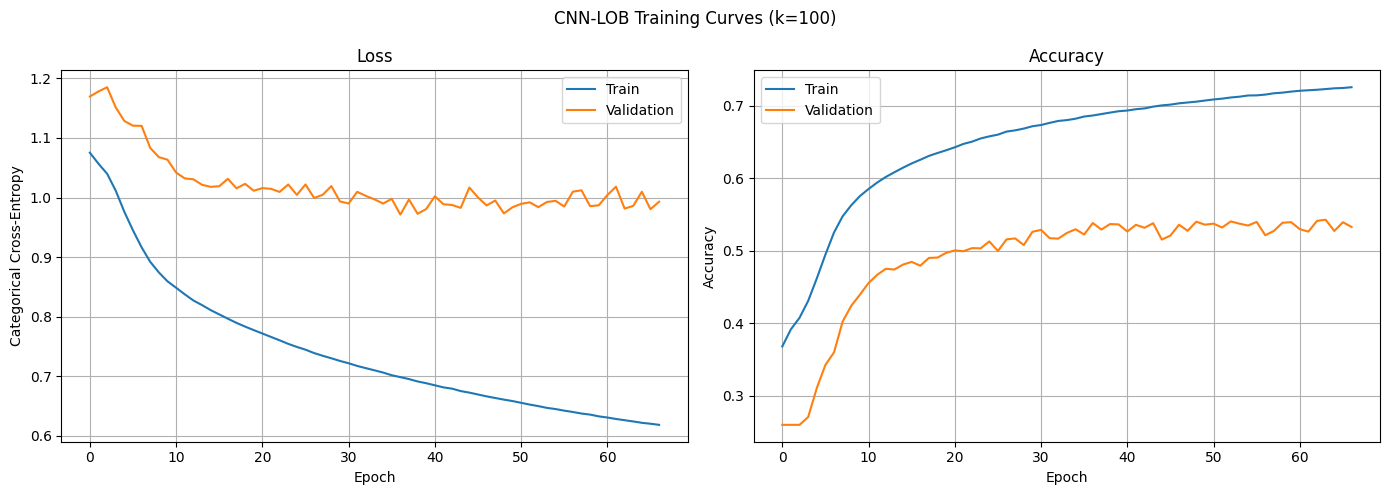

In [20]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history.history['loss'], label='Train')
ax1.plot(history.history['val_loss'], label='Validation')
ax1.set_title('Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Categorical Cross-Entropy')
ax1.legend()
ax1.grid(True)

ax2.plot(history.history['accuracy'], label='Train')
ax2.plot(history.history['val_accuracy'], label='Validation')
ax2.set_title('Accuracy')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True)

plt.suptitle('CNN-LOB Training Curves (k=100)')
plt.tight_layout()
plt.show()

## Experiment: Custom Labels at k=20

The FI-2010 dataset labels use a fixed labeling scheme. Here we implement the labeling method from Tsantekidis et al. (2017) Equations 3-5 to compute custom labels with a tunable threshold α, and sweep α values to find a balanced class distribution at k=20.

In [15]:
def compute_custom_labels(data, k, alpha):
    """Tsantekidis et al. (2017) Equations 3-5."""
    mid_price = (data[0, :] + data[2, :]) / 2.0
    N = len(mid_price)
    labels = np.ones(N, dtype=int)
    for t in range(k, N - k):
        mb = np.mean(mid_price[t-k:t+1])
        ma = np.mean(mid_price[t+1:t+k+1])
        if mb > ma * (1 + alpha):
            labels[t] = 0
        elif mb < ma * (1 - alpha):
            labels[t] = 2
    return labels

In [16]:
from collections import Counter
print("Alpha sweep for k=20 custom labels (training set):")
print(f"{'alpha':>10} {'down':>8} {'stat':>8} {'up':>8}")
for alpha in [0.002, 0.001, 0.0005, 0.0003, 0.0002, 0.0001, 0.00005]:
    labels = compute_custom_labels(dec_train, k=20, alpha=alpha)
    c = Counter(labels)
    total = len(labels)
    print(f"{alpha:>10.5f} {c[0]/total:>8.1%} {c[1]/total:>8.1%} {c[2]/total:>8.1%}")

Alpha sweep for k=20 custom labels (training set):
     alpha     down     stat       up
   0.00200     1.6%    96.8%     1.6%
   0.00100    12.9%    75.0%    12.0%
   0.00050    26.6%    47.1%    26.3%
   0.00030    33.6%    32.5%    33.9%
   0.00020    37.7%    24.0%    38.3%
   0.00010    42.4%    14.4%    43.3%
   0.00005    45.1%     8.7%    46.2%


## Hyperparameter Sweep: k=20 Custom Labels

Comparing 4 configurations to find the best setup for k=20 mid-price forecasting with custom Tsantekidis et al. (2017) labels.

**Data normalization:** Using the official FI-2010 ZScore-normalized files from `data/full/BenchmarkDatasets/NoAuction/1.NoAuction_Zscore/`.

**Variables:** normalization (DecPre vs ZScore), alpha threshold (0.0003 vs 0.0005), batch size (16 vs 64), dropout (0.0 vs 0.25).

In [17]:
def split_by_day(data, train_ratio=0.8):
    """Split each stock's data by time, then recombine.
    
    The training file contains 7 days x 5 stocks concatenated.
    Each stock has roughly equal number of events.
    We split each stock's portion 80/20 by time, keeping
    all 5 stocks in both train and val.
    """
    total_cols = data.shape[1]
    n_stocks = 5
    stock_size = total_cols // n_stocks
    
    train_parts = []
    val_parts = []
    
    for i in range(n_stocks):
        start = i * stock_size
        end = start + stock_size if i < n_stocks - 1 else total_cols
        stock_data = data[:, start:end]
        split_idx = int(stock_data.shape[1] * train_ratio)
        train_parts.append(stock_data[:, :split_idx])
        val_parts.append(stock_data[:, split_idx:])
    
    return np.hstack(train_parts), np.hstack(val_parts)

In [18]:
# Load ZScore-normalized data from data/extracted/ (same dir as DecPre)
zscore_data = np.loadtxt(os.path.join(data_dir, 'Train_Dst_NoAuction_ZScore_CF_7.txt'))
zscore_test = np.hstack((
    np.loadtxt(os.path.join(data_dir, 'Test_Dst_NoAuction_ZScore_CF_7.txt')),
    np.loadtxt(os.path.join(data_dir, 'Test_Dst_NoAuction_ZScore_CF_8.txt')),
    np.loadtxt(os.path.join(data_dir, 'Test_Dst_NoAuction_ZScore_CF_9.txt'))
))

print(f"ZScore train data: {zscore_data.shape}")
print(f"ZScore test data:  {zscore_test.shape}")
print(f"Feature stats — mean: {zscore_data[:40,:].mean():.4f}, std: {zscore_data[:40,:].std():.4f}")

ZScore train data: (149, 254750)
ZScore test data:  (149, 139587)
Feature stats — mean: 0.0000, std: 1.0000


In [19]:
def run_experiment(data_full, data_test, alpha, batch_size, dropout_rate, label, k_horizon=20, T=100):
    """Run one training experiment and return results dict."""
    # Split by stock
    train_data, val_data = split_by_day(data_full, train_ratio=0.8)
    
    # Custom labels
    train_labels = compute_custom_labels(train_data, k=k_horizon, alpha=alpha)
    val_labels = compute_custom_labels(val_data, k=k_horizon, alpha=alpha)
    test_labels = compute_custom_labels(data_test, k=k_horizon, alpha=alpha)
    
    # Build windowed datasets
    trainX = prepare_x(train_data)
    valX = prepare_x(val_data)
    testX = prepare_x(data_test)
    
    trainX_w, _ = data_classification(trainX, train_labels.reshape(-1,1), T)
    valX_w, _ = data_classification(valX, val_labels.reshape(-1,1), T)
    testX_w, _ = data_classification(testX, test_labels.reshape(-1,1), T)
    
    trainY = to_categorical(train_labels[T-1:], 3)
    valY = to_categorical(val_labels[T-1:], 3)
    testY = to_categorical(test_labels[T-1:], 3)
    
    print(f"\n--- {label} ---")
    print(f"Train: {Counter(np.argmax(trainY, axis=1))}")
    print(f"Val:   {Counter(np.argmax(valY, axis=1))}")
    print(f"Test:  {Counter(np.argmax(testY, axis=1))}")
    
    # Fresh model
    model = create_cnnlob(T, 40, dropout_rate=dropout_rate)
    
    cp_path = f'./model_cnnlob_2017/weights_{label}.weights.h5'
    callbacks = [
        tf.keras.callbacks.ModelCheckpoint(filepath=cp_path, save_weights_only=True, monitor='val_loss', save_best_only=True),
        tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=30, restore_best_weights=True)
    ]
    
    history = model.fit(trainX_w, trainY, validation_data=(valX_w, valY),
                       epochs=100, batch_size=batch_size, verbose=2, callbacks=callbacks)
    
    model.load_weights(cp_path)
    pred = model.predict(testX_w)
    
    report = classification_report(np.argmax(testY, axis=1), np.argmax(pred, axis=1), digits=4, output_dict=True)
    acc = accuracy_score(np.argmax(testY, axis=1), np.argmax(pred, axis=1))
    
    print(f"\n{'='*60}")
    print(f"Experiment: {label}")
    print(f"Test Accuracy: {acc:.4f}")
    print(f"Macro F1: {report['macro avg']['f1-score']:.4f}")
    print(f"Weighted F1: {report['weighted avg']['f1-score']:.4f}")
    print(classification_report(np.argmax(testY, axis=1), np.argmax(pred, axis=1), digits=4))
    print(f"{'='*60}\n")
    
    return {'label': label, 'accuracy': acc, 'macro_f1': report['macro avg']['f1-score'],
            'weighted_f1': report['weighted avg']['f1-score'], 'history': history}

In [ ]:
%%time

results = []

# Experiment A: Current best (DecPre, alpha=0.0005, batch=64, dropout=0.25)
results.append(run_experiment(dec_data, dec_test, alpha=0.0005, batch_size=64, dropout_rate=0.25, label='A_decpre_a0005_b64_d025'))

# Experiment B: Paper settings (ZScore, alpha=0.0003, batch=16, no dropout)
results.append(run_experiment(zscore_data, zscore_test, alpha=0.0003, batch_size=16, dropout_rate=0.0, label='B_zscore_a0003_b16_d000'))

# Experiment C: ZScore + balanced alpha + dropout (ZScore, alpha=0.0005, batch=16, dropout=0.25)
results.append(run_experiment(zscore_data, zscore_test, alpha=0.0005, batch_size=16, dropout_rate=0.25, label='C_zscore_a0005_b16_d025'))

# Experiment D: ZScore + tight alpha + small batch (ZScore, alpha=0.0003, batch=16, dropout=0.25)
results.append(run_experiment(zscore_data, zscore_test, alpha=0.0003, batch_size=16, dropout_rate=0.25, label='D_zscore_a0003_b16_d025'))


--- A_decpre_a0005_b64_d025 ---
Train: Counter({np.int64(1): 100309, np.int64(2): 51816, np.int64(0): 51576})
Val:   Counter({np.int64(1): 26480, np.int64(0): 12897, np.int64(2): 11474})
Test:  Counter({np.int64(1): 93023, np.int64(2): 24545, np.int64(0): 21920})
Epoch 1/100
3183/3183 - 12s - 4ms/step - accuracy: 0.4925 - loss: 1.0347 - val_accuracy: 0.5207 - val_loss: 0.9960
Epoch 2/100
3183/3183 - 10s - 3ms/step - accuracy: 0.4924 - loss: 1.0285 - val_accuracy: 0.5197 - val_loss: 0.9929
Epoch 3/100
3183/3183 - 11s - 3ms/step - accuracy: 0.4944 - loss: 1.0225 - val_accuracy: 0.5250 - val_loss: 0.9898
Epoch 4/100
3183/3183 - 12s - 4ms/step - accuracy: 0.4995 - loss: 1.0161 - val_accuracy: 0.5218 - val_loss: 0.9829
Epoch 5/100
3183/3183 - 12s - 4ms/step - accuracy: 0.5069 - loss: 1.0064 - val_accuracy: 0.5199 - val_loss: 0.9751
Epoch 6/100
3183/3183 - 14s - 4ms/step - accuracy: 0.5120 - loss: 0.9976 - val_accuracy: 0.5261 - val_loss: 0.9756
Epoch 7/100
3183/3183 - 13s - 4ms/step - accu

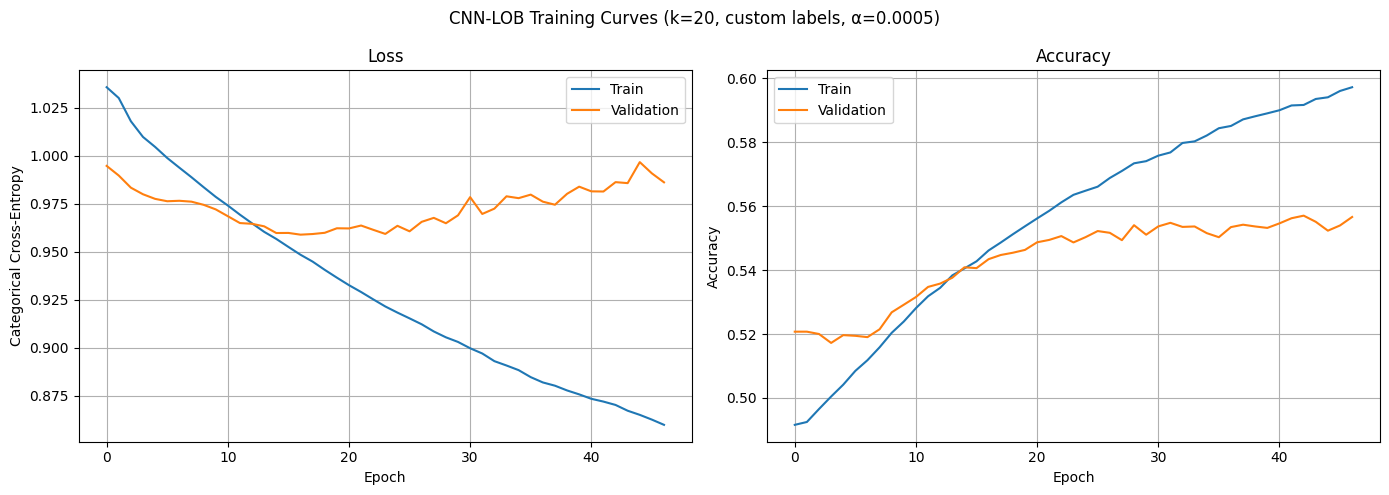

In [ ]:
print(f"\n{'='*75}")
print(f"{'Experiment':<40} {'Accuracy':>10} {'Macro F1':>10} {'Weighted F1':>12}")
print("-" * 75)
for r in results:
    print(f"{r['label']:<40} {r['accuracy']:>10.4f} {r['macro_f1']:>10.4f} {r['weighted_f1']:>12.4f}")
print(f"{'='*75}")

# Find best by macro F1
best = max(results, key=lambda x: x['macro_f1'])
print(f"\nBest by Macro F1: {best['label']} ({best['macro_f1']:.4f})")

In [12]:
import subprocess, platform
if platform.system() == "Windows":
    subprocess.run(["shutdown", "/h"])
    print("Hibernating...")
else:
    print("Not on Windows, skipping auto-hibernate")

Hibernating...
